# 🧪 01 - Exploratory Data Analysis (EDA)
This notebook explores the UCI Diabetes 130-Hospitals dataset to understand the features,
target distribution, and potential issues like missing data or class imbalance.

**Goals:**
- Understand the structure of the data
- Identify missing or problematic values
- Explore relationships between features and readmission status

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='whitegrid')

In [2]:
# Load the dataset
data_path = '../data/diabetic_data.csv'  # adjust path if needed
df = pd.read_csv(data_path)
df.shape

(101766, 50)

## 🔍 Basic Dataset Overview

In [3]:
# Show the first few rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.replace("?", np.nan, inplace=True)

In [5]:
# Check for null values
df.isnull().sum().sort_values(ascending=False).head(20)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
dtype: int64

## 🎯 Target Variable Analysis

In [6]:
# Analyze target variable (e.g., 'readmitted')
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
# Optional: Convert to binary classification if needed
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df['readmitted_binary'].value_counts(normalize=True)

readmitted_binary
0    0.888401
1    0.111599
Name: proportion, dtype: float64

### 📊 Visualizing Target Variable Distribution
Bar plots to visualize the class distribution of the `readmitted` variable.

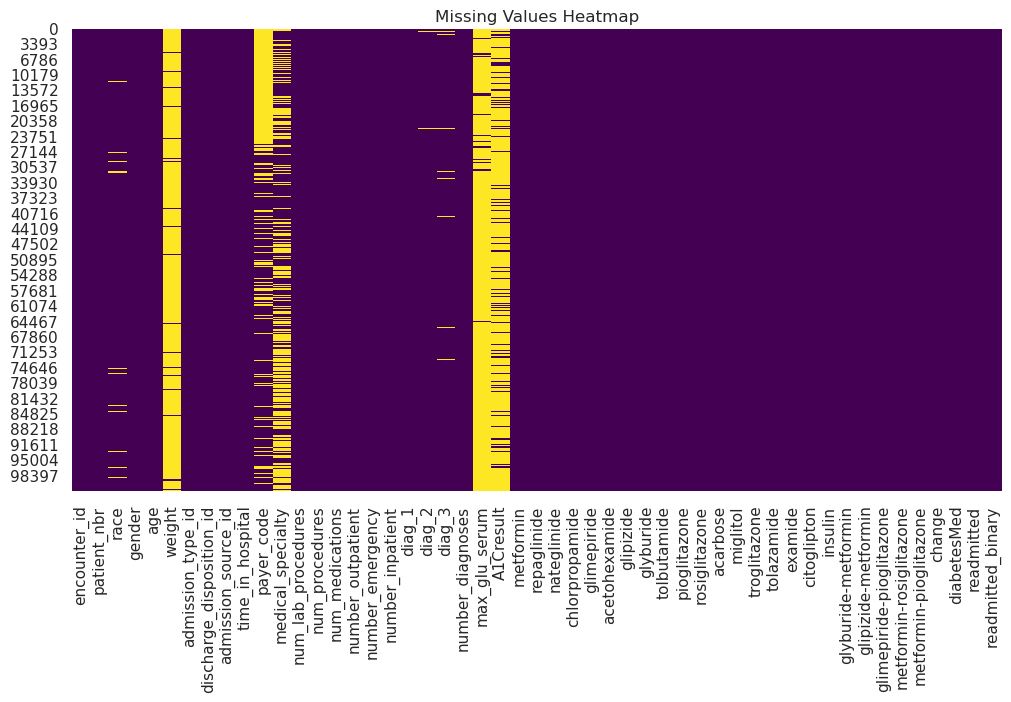

In [8]:
# Visualize missing values (if any are NaN)
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

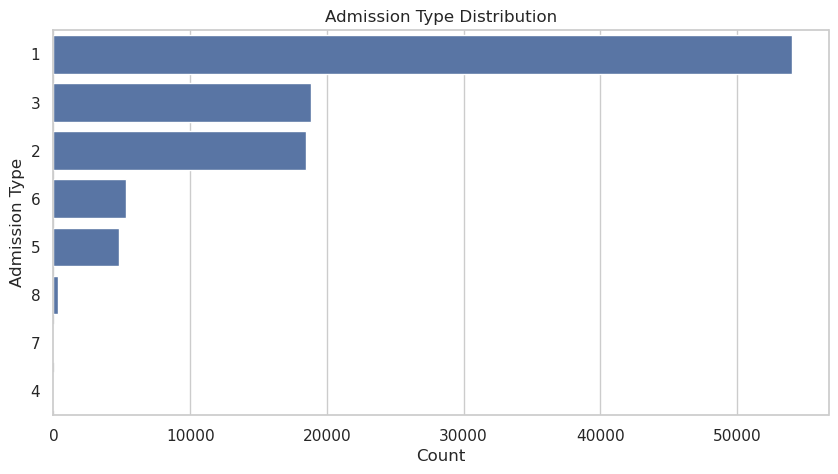

In [9]:
# Plot top 10 most common admission types
plt.figure(figsize=(10, 5))
sns.countplot(y='admission_type_id', data=df, order=df['admission_type_id'].value_counts().index)
plt.title('Admission Type Distribution')
plt.xlabel('Count')
plt.ylabel('Admission Type')
plt.show()

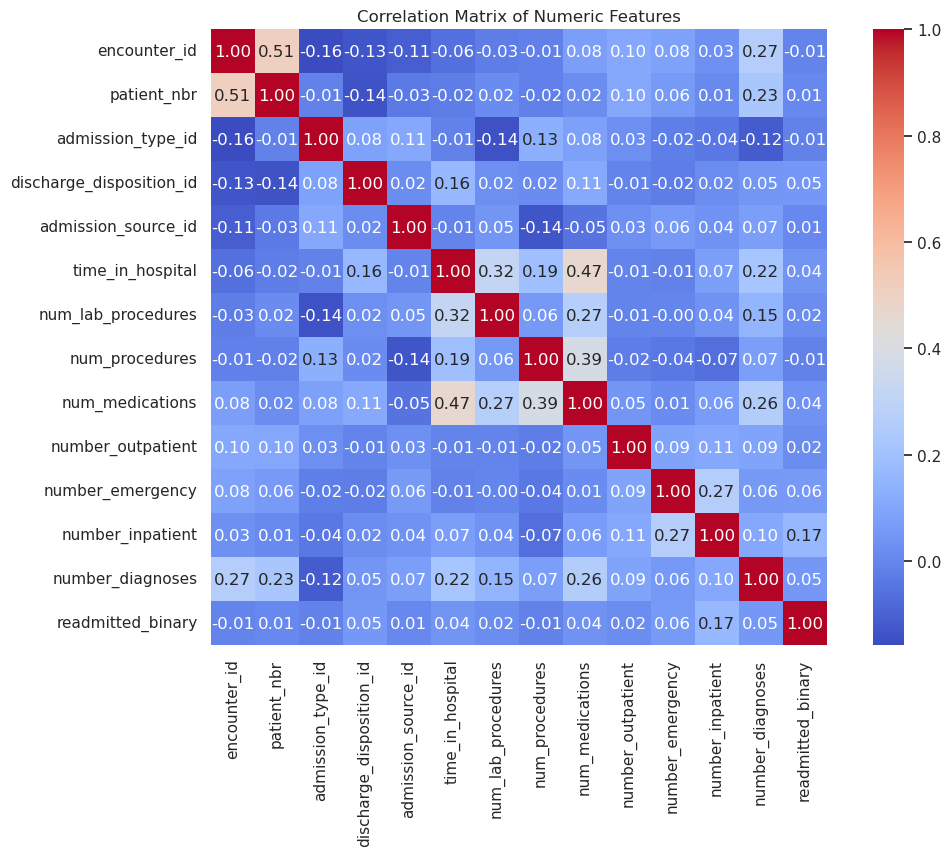

In [10]:
# Only keep numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

## 📊 Feature Distribution & Cleaning
- Visualize top categorical columns
- Drop or encode high-cardinality fields
- Remove columns with too many missing or meaningless values

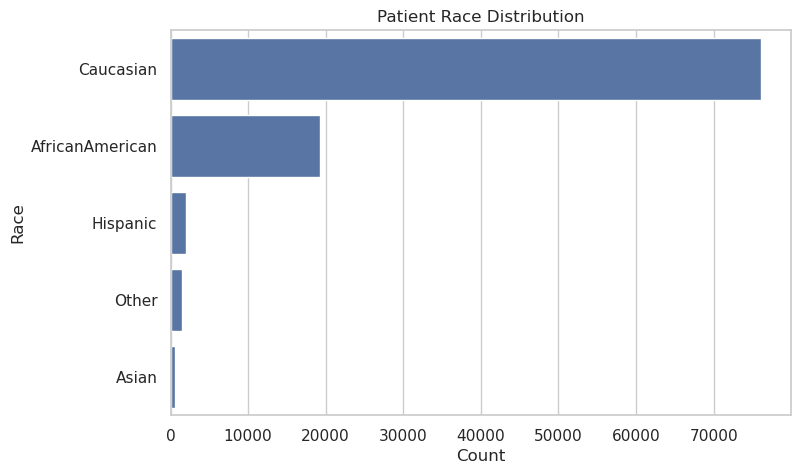

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(y='race', data=df, order=df['race'].value_counts().index)
plt.title('Patient Race Distribution')
plt.xlabel('Count')
plt.ylabel('Race')
plt.show()

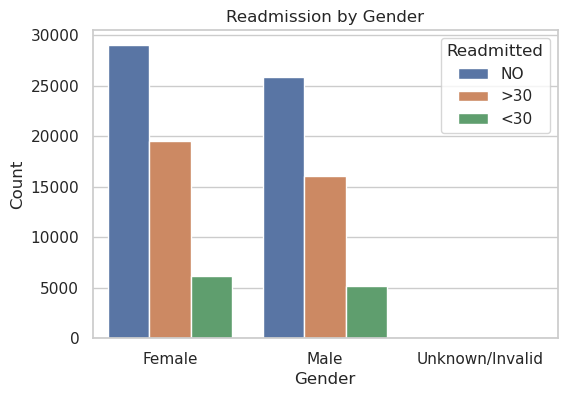

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='readmitted', data=df)
plt.title('Readmission by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Readmitted')
plt.show()

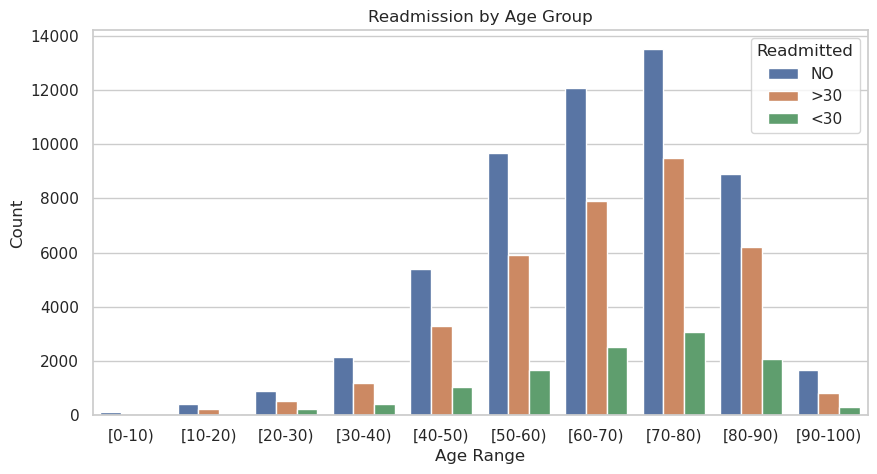

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(x='age', hue='readmitted', data=df, order=sorted(df['age'].unique()))
plt.title('Readmission by Age Group')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.legend(title='Readmitted')
plt.show()

In [14]:
# Drop columns with extremely high cardinality or unclear use
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

# Optional: inspect cardinality of other fields
df.nunique().sort_values(ascending=False).head(10)

diag_3                      789
diag_2                      748
diag_1                      716
num_lab_procedures          118
num_medications              75
medical_specialty            72
number_outpatient            39
number_emergency             33
discharge_disposition_id     26
number_inpatient             21
dtype: int64

In [15]:
df.replace("?", np.nan, inplace=True)

### ✅ Cleaning Summary
- Dropped high-cardinality identifiers: `encounter_id`, `patient_nbr`
- Dropped mostly missing or low-utility fields: `weight`, `payer_code`
- Replaced `"?"` with `NaN` and confirmed remaining missing values
- Visualized `race`, `gender`, and `age` — showing imbalance and patterns in readmission